# Unemployment Analysis in India using Python

This project analyzes unemployment trends in India using a dataset that
contains unemployment rates, employment numbers, and labour participation rates.

The aim is to explore patterns in unemployment and understand how the
COVID-19 pandemic affected unemployment rates across different states.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

df.info()

Dataset Shape: (267, 9)

Column Names:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 

In [4]:
df.columns = df.columns.str.strip()

In [5]:
df = df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
})

In [6]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Unemployment_Rate,0
Employed,0
Labour_Participation_Rate,0
Region.1,0
longitude,0
latitude,0


In [7]:
df = df.dropna()

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_177/2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [9]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [10]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,longitude,latitude,Month,Year
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000,267.000000,267.0
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425,5.535581,2020.0
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400,1.000000,2020.0
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600,3.000000,2020.0
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300,6.000000,2020.0
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900,8.000000,2020.0
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600,10.000000,2020.0
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738,2.870915,0.0


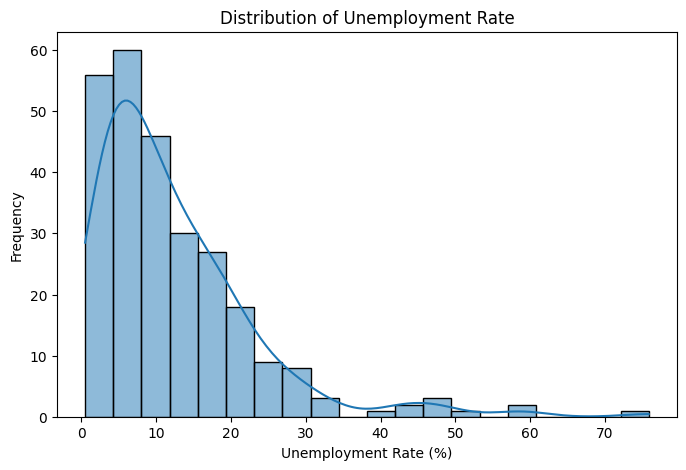

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Unemployment_Rate'], bins=20, kde=True)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")

plt.show()

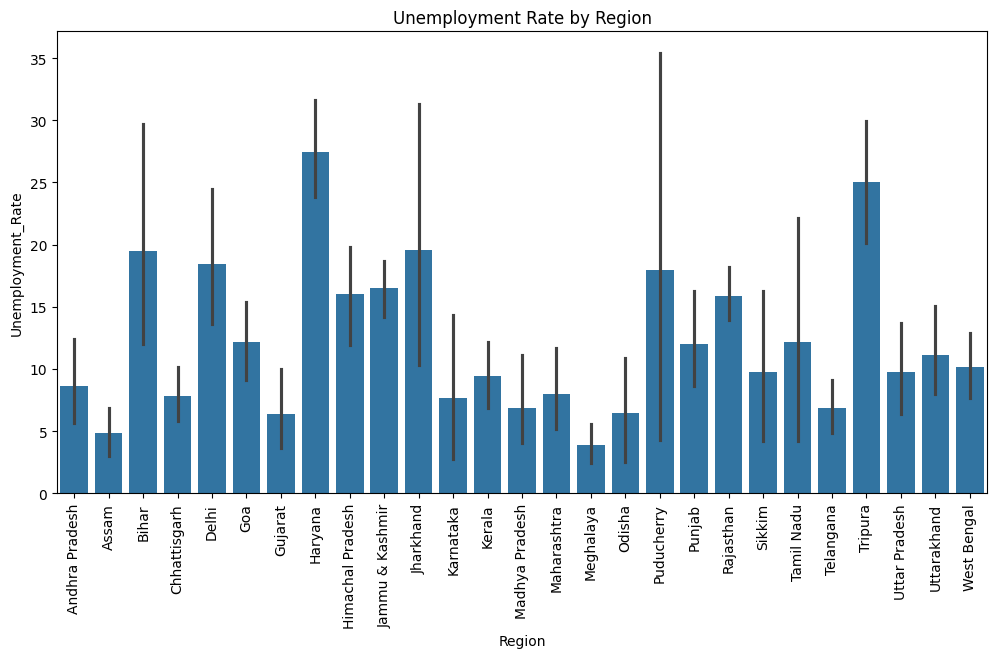

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(x='Region', y='Unemployment_Rate', data=df)

plt.xticks(rotation=90)
plt.title("Unemployment Rate by Region")

plt.show()

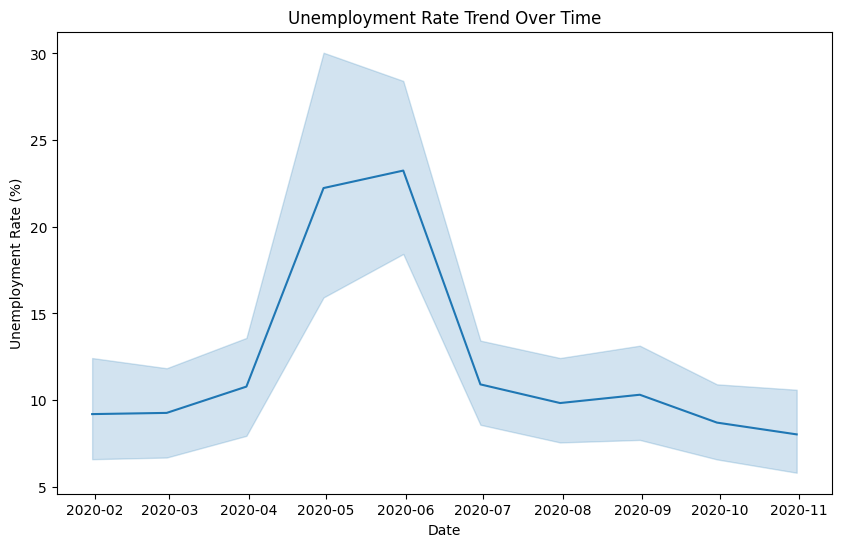

In [13]:
plt.figure(figsize=(10,6))

sns.lineplot(x='Date', y='Unemployment_Rate', data=df)

plt.title("Unemployment Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.show()

In [14]:
covid_data = df[df['Year'] == 2020]

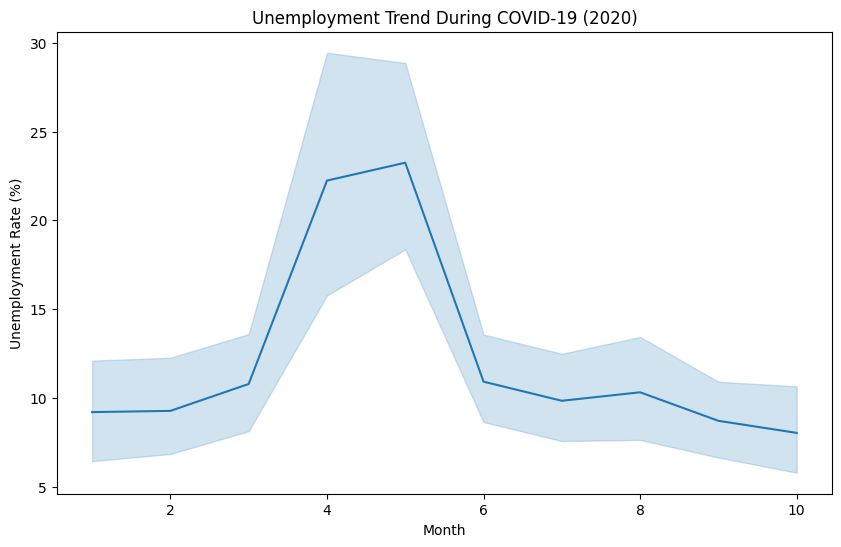

In [15]:
plt.figure(figsize=(10,6))

sns.lineplot(x='Month', y='Unemployment_Rate', data=covid_data)

plt.title("Unemployment Trend During COVID-19 (2020)")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")

plt.show()

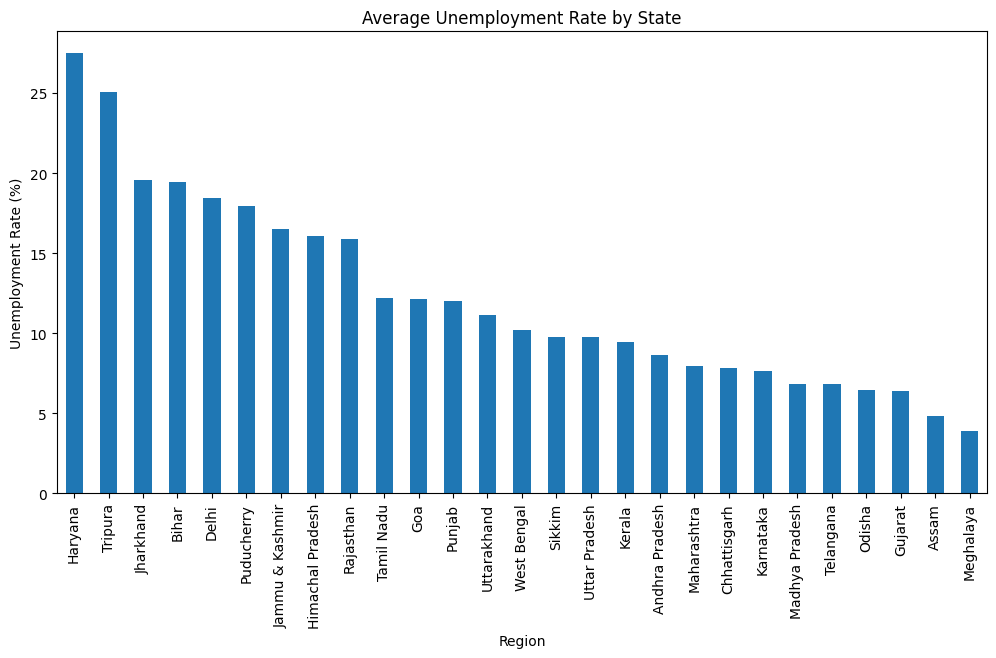

In [16]:
state_unemployment = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

state_unemployment.plot(kind='bar')

plt.title("Average Unemployment Rate by State")
plt.ylabel("Unemployment Rate (%)")

plt.show()

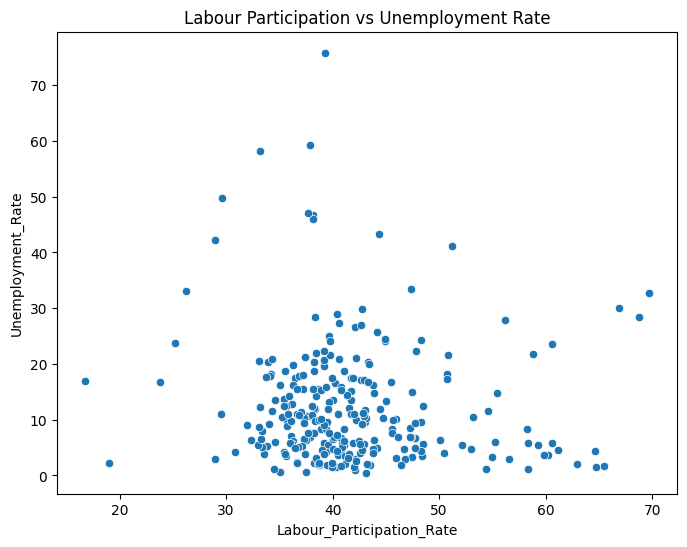

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Labour_Participation_Rate',
    y='Unemployment_Rate',
    data=df
)

plt.title("Labour Participation vs Unemployment Rate")

plt.show()

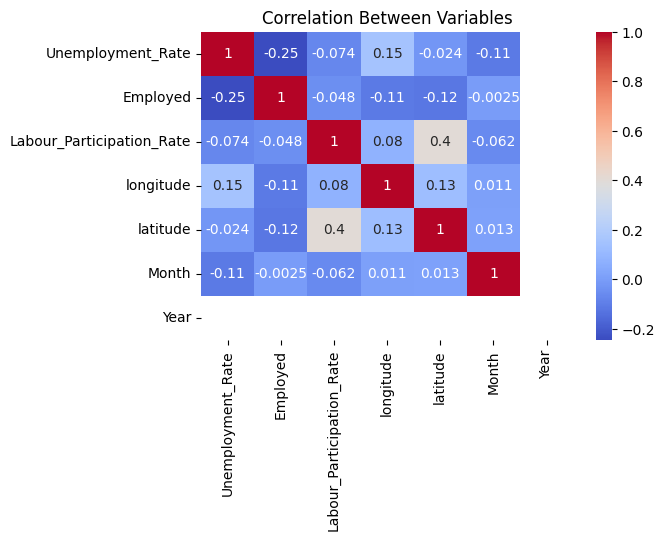

In [19]:
plt.figure(figsize=(6,4))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Between Variables")

plt.show()

## Conclusion

In this project, unemployment trends in India were analyzed using Python.
Different visualizations were used to understand how unemployment varies
across states and over time.

The analysis also highlights the impact of the COVID-19 pandemic on
unemployment rates.

Such analysis can help policymakers understand labour market trends
and design better employment strategies.